Title: Assignment 6

Question 1: WAP to enhance the input image using histogram equalization.

(np.float64(-0.5), np.float64(4102.5), np.float64(3003.5), np.float64(-0.5))

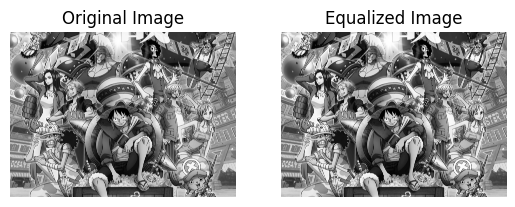

In [6]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("img1.jpg")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
final_img = cv2.equalizeHist(gray) 

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(final_img, cmap='gray')
plt.title('Equalized Image')
plt.axis('off')

Question 2: WAP to match the histogram of the input image with that of reference image using histogram matching technique.

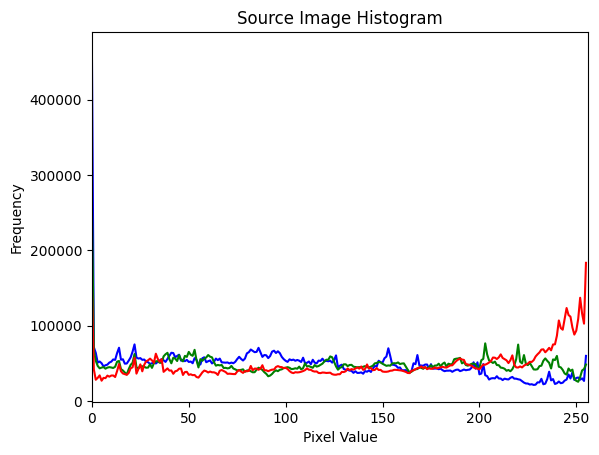

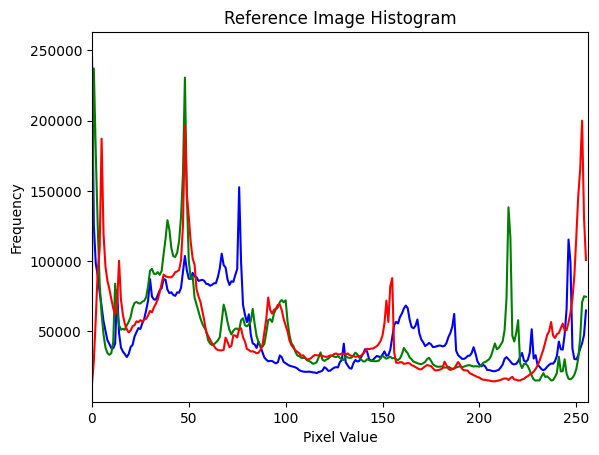

[ 49  62 159 112 128 161 112 111 131 120 127 127 110 147 241 147  67  84
 107 233 149  61  23  83 234 240 147 240  77  21 151  21 244  93 243  76
  17 104 148 149 103 103  83 147  72  70  79 126 104 104 107  84 130 140
 110 113 130 144 103 147 142  71 145 145  81 126  72 148  63 104 141  83
  82 106 106  71 148  71 233  63 147  72  78 103  79  79 148  79  73 103
 103 147 103  62  62 239  78 239  61 102 102 234 147  80  65 145 142 145
 146 147 148 149  62 148 147  71  71  68  65  80 143  68 233 143 156  86
 107  84  84 104 104 147  79 148 234  62  79  61  79  69 148 234 240  79
 102 148 148 102 148 148  71 146 146  71  72 103 148 148 148 103 103 147
 104  68  65  72 103  62 102 102  75 102 239 234 149 234  79  61  79  61
  61 239  61  61  69  74  74 101  77  22 246  22  22 241 240  73  60  61
 149  70  62 239 240 240  19 245  77  23  23 243  58  16  26  17  21 236
 100  29 240  61  61  75  61  60 240  59  76  76 100  28  16  57  96  96
  57  32  33  32  55  55   8   4   7  45   4  47  5

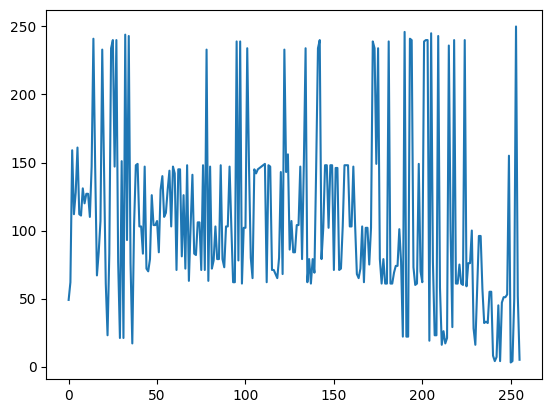

In [22]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

src = cv2.imread("img1.jpg")
ref = cv2.imread("img2.jpg")

ref = cv2.resize(ref, (src.shape[1], src.shape[0]))

def display_histogram(image, title):
    color = ('b', 'g', 'r')
    plt.figure()
    plt.title(title)
    plt.xlabel('Pixel Value')
    plt.ylabel('Frequency')
    values = []
    for i, col in enumerate(color):
        hist = cv2.calcHist([image], [i], None, [256], [0, 256])
        values = hist.copy()
        plt.plot(hist, color=col)
        plt.xlim([0, 256])
    plt.show()
    return values

img1_vals = display_histogram(src, 'Source Image Histogram').flatten()
img2_vals = display_histogram(ref, 'Reference Image Histogram').flatten()

matched_vals = img1_vals.copy()
color = ('b', 'g', 'r')
for i in range(256):
    diff = np.abs(img1_vals[i] - img2_vals)
    matched_vals[i] = np.argmin(diff)
matched_vals = matched_vals.astype(np.uint8)
print(matched_vals)

plt.plot(matched_vals)

Question 3: WAP to smooth the input image using:
(a) Averaging Filter (un-weighted)
(b) Weighted filter given by h(*x, y) = max(|x|, |y|)
(c) Gaussian Filter

(np.float64(-0.5), np.float64(4102.5), np.float64(3003.5), np.float64(-0.5))

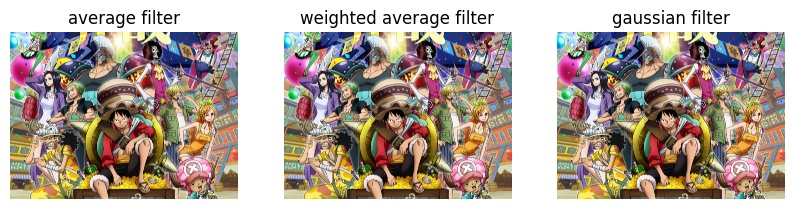

In [27]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

src = cv2.imread("img1.jpg")

# average filter
dst1 = cv2.blur(src, (5, 5))

# weighted average filter
dst2 = cv2.boxFilter(src, -1, (5, 5), normalize=True)

# gaussian filter
dst3 = cv2.GaussianBlur(src, (5, 5), 0)

plt.figure(figsize=(10, 7))
plt.subplot(1, 3, 1)
plt.title("average filter")
plt.imshow(cv2.cvtColor(dst1, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.subplot(1, 3, 2)
plt.title("weighted average filter")
plt.imshow(cv2.cvtColor(dst2, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.subplot(1, 3, 3)
plt.title("gaussian filter")
plt.imshow(cv2.cvtColor(dst3, cv2.COLOR_BGR2RGB))
plt.axis("off")